In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from collections import Counter
import numpy as np

C:\Users\omtr0\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset = load_dataset("imdb")

train_data = dataset["train"]
test_data = dataset["test"]

train_df = pd.DataFrame(train_data)

train_df.head()

,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


In [3]:
print("Shape:", train_df.shape)
print("\nClass distribution:\n", train_df["label"].value_counts())

Shape: (25000, 2)

Class distribution:
 label
0    12500
1    12500
Name: count, dtype: int64


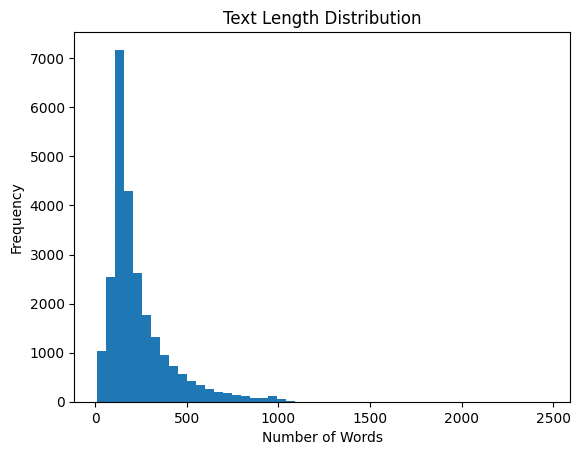

In [4]:
train_df["length"] = train_df["text"].apply(lambda x: len(x.split()))

plt.hist(train_df["length"], bins=50)
plt.title("Text Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

In [5]:
pos_len = train_df[train_df["label"] == 1]["length"]
neg_len = train_df[train_df["label"] == 0]["length"]

print("Avg Positive Length:", pos_len.mean())
print("Avg Negative Length:", neg_len.mean())

Avg Positive Length: 236.70656
Avg Negative Length: 230.86784


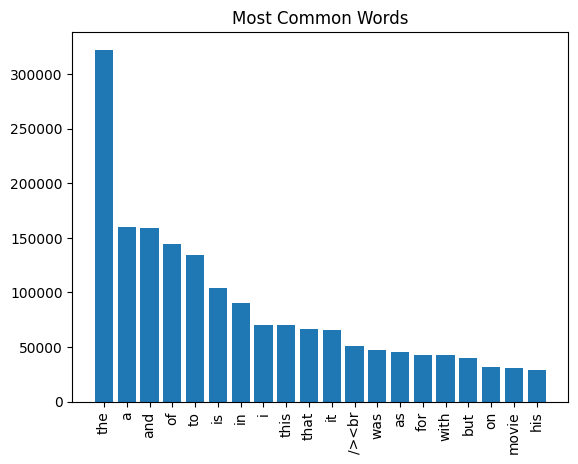

In [6]:
all_words = " ".join(train_df["text"]).lower().split()

common_words = Counter(all_words).most_common(20)

words, counts = zip(*common_words)

plt.bar(words, counts)
plt.xticks(rotation=90)
plt.title("Most Common Words")
plt.show()